### Before Integration

### Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import re
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel


In [2]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
# load dataset

freelancer = pd.read_excel("Freelancer_data.xlsx")
guru       = pd.read_excel("Guru_data.xlsx")
upwork     = pd.read_excel("UPWork_data.xlsx")

print("Datasets loaded successfully")

Datasets loaded successfully


In [6]:
for name, df in [("Freelancer", freelancer), ("Guru", guru), ("Upwork", upwork)]:
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape   : {df.shape}")
    print(f"  Columns : {df.columns.tolist()}")
    print()
    display(df.head())
    print()

  Freelancer
  Shape   : (4968, 14)
  Columns : ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Skill7', 'Skill8', 'Skill9', 'Bids', 'Price']



,Title,Description,Link,Skill1,Skill2,Skill3,Skill4,Skill5,Skill6,Skill7,Skill8,Skill9,Bids,Price
0,Modern Business Card Design Needed,"I’m looking for a sleek, modern visiting card ...",https://www.freelancer.com/projects/adobe-illu...,Adobe Illustrator,Adobe Photoshop,Business Card Design,Creative Design,Graphic Design,Logo Design,Photoshop,Print Design,NaN,0 bids,$17 - $138
1,Employment History Verification – France,I am running a pre-employment vetting project ...,https://www.freelancer.com/projects/data-prote...,Customer Service,Data Collection,Data Management,Data Protection,Documentation,Human Resources,Local Job,Report Writing,Research,0 bids,$10 - $45
2,Fix Admin Panel Bugs,Our PHP-based admin panel has suddenly become ...,https://www.freelancer.com/projects/debugging/...,AJAX,Debugging,JavaScript,MVC,MySQL,PHP,Software Development,Web Development,NaN,0 bids,$7 - $17
3,Instagram DM Keyword Automation System,I want an end-to-end solution that watches eve...,https://www.freelancer.com/projects/api/instag...,API,Automation,C# Programming,Instagram API,Node.js,PHP,Python,Software Architecture,Web Development,0 bids,$138 - $414
4,Crear una página web portal para Escorts - 17/...,Se requiere desarrollar una pagina web para es...,https://www.freelancer.com/contest/crear-una-p...,Graphic Design,HTML,PHP,Website Design,NaN,NaN,NaN,NaN,NaN,0 entries,10



  Guru
  Shape   : (435, 11)
  Columns : ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Bids', 'Price']



,Title,Description,Link,Skill1,Skill2,Skill3,Skill4,Skill5,Skill6,Bids,Price
0,"Laravel (backend) + React (Web, Mobile)",Below is a work scope document a Laravel (back...,https://www.guru.com/jobs/laravel-backend-reac...,Python,API Development,Mobile Web Design,Payment Gateway Integration,Software Development,Artificial Intelligence,5,$500-$1k
1,"React Full-Stack Engineer (Web, Mobile)",Project is a 3D creation platform powered by A...,https://www.guru.com/jobs/react-full-stack-eng...,CGI,Java,JSON,Open Source,3D Animation,Programming,21,$500-$1k
2,Photo Editing for Overhead Crane Company,IMPORTANT: Responses must be submitted directl...,https://www.guru.com/jobs/photo-editing-for-ov...,Adobe Photoshop,Adobe Lightroom,Color Balancing,Image Design,Photo and Image Editing,Watermarking,18,NaN
3,5Star !!! WordPress Developer Needed UK,WordPress Developer Needed – Booking + Members...,https://www.guru.com/jobs/5star-wordpress-deve...,WordPress,Web Design,Web Development,WooCommerce,E Commerce,Content Management Systems,2,NaN
4,Migrate Algo to Web App,I am looking for a long-term technical partner...,https://www.guru.com/jobs/migrate-algo-to-web-...,NaN,NaN,NaN,NaN,NaN,NaN,72,NaN



  Upwork
  Shape   : (1064, 11)
  Columns : ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Bids', 'Price', 'Level']



,Title,Description,Link,Skill1,Skill2,Skill3,Skill4,Skill5,Bids,Price,Level
0,Mobile Network Testers – Regional Support (Par...,Description:\nWe are seeking reliable freelanc...,https://www.upwork.com/jobs/Mobile-Network-Tes...,Administrative Support,Functional Testing,Mobile App Testing,Manual Testing,Automated Testing,Less than 5,100,Entry level
1,Testing Arabic Localization App,The goal is to test the Arabic localization of...,https://www.upwork.com/jobs/Testing-Arabic-Loc...,Arabic,English to Arabic Translation,Manual Testing,Software QA,NaN,5 to 10,30,Intermediate
2,Server Integrity & Security Audit,"Evaluate the current performance, stability, a...",https://www.upwork.com/jobs/Server-Integrity-S...,Cybersecurity Management,Network Security,Firewall,Information Security,Vulnerability Assessment,5 to 10,200,Intermediate
3,PDF to Excel Data Entry Specialist | Data Proc...,We are seeking a skilled Data Entry Specialist...,https://www.upwork.com/jobs/PDF-Excel-Data-Ent...,Data Entry,Microsoft Excel,Spreadsheet Software,Administrative Support,Microsoft Word,20 to 50,8,Expert
4,Collaborateur pour la création d'agent IA,**Offre d'emploi : Développeur Freelance en In...,https://www.upwork.com/jobs/Collaborateur-pour...,English to French Translation,n8n,no code,automatisation,NaN,Less than 5,150,Intermediate


### Data Understanding & EDA

In [4]:
def eda(df, name):
    print(f"{'='*55}\n  {name}\n{'='*55}")
    
    # Missing values
    mv = df.isnull().sum()
    mv_pct = (mv / len(df) * 100).round(2)
    mv_df = pd.DataFrame({"Missing": mv, "Missing %": mv_pct})
    mv_df = mv_df[mv_df["Missing"] > 0]
    print("\n Missing Values:")
    display(mv_df if len(mv_df) else pd.DataFrame({"Result": ["None"]}))
    
    # Duplicates
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    
    # Column types
    num_cols = df.select_dtypes(include="number").columns.tolist()
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    print(f"\nNumerical: {num_cols}")
    print(f"Categorical: {cat_cols}")
    
    # Summary stats
    if num_cols:
        print("\nNumeric Summary:")
        display(df[num_cols].describe())
    print()

In [5]:
eda(freelancer, "Freelancer")

  Freelancer

 Missing Values:


,Missing,Missing %
Description,1,0.02
Skill2,2,0.04
Skill3,122,2.46
Skill4,207,4.17
Skill5,337,6.78
Skill6,535,10.77
Skill7,718,14.45
Skill8,1066,21.46
Skill9,3459,69.63
Bids,47,0.95



Duplicate rows: 0

Numerical: []
Categorical: ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Skill7', 'Skill8', 'Skill9', 'Bids', 'Price']



In [6]:
eda(guru, "Guru")

  Guru

 Missing Values:


,Missing,Missing %
Skill1,28,6.44
Skill2,87,20.00
Skill3,127,29.20
Skill4,180,41.38
Skill5,230,52.87
Skill6,301,69.20
Bids,73,16.78
Price,147,33.79



Duplicate rows: 0

Numerical: []
Categorical: ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Bids', 'Price']



In [7]:
eda(upwork, "Upwork")

  Upwork

 Missing Values:


,Missing,Missing %
Skill1,2,0.19
Skill2,93,8.74
Skill3,161,15.13
Skill4,265,24.91
Skill5,504,47.37
Price,422,39.66



Duplicate rows: 294

Numerical: []
Categorical: ['Title', 'Description', 'Link', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Bids', 'Price', 'Level']



### Data Cleaning

In [8]:
# Price Column
def parse_price(val):
    if pd.isna(val) or str(val).strip() in ("", "nan"):
        return np.nan, np.nan
    s = str(val).replace(",", "").replace("USD", "").replace("/hr", "").strip()
    # expand shorthand k → 000
    s = re.sub(r"(\d+\.?\d*)k", lambda m: str(float(m.group(1)) * 1000), s, flags=re.IGNORECASE)
    nums = list(map(float, re.findall(r"\d+(?:\.\d+)?", s)))
    if not nums:
        return np.nan, np.nan
    return (nums[0], nums[0]) if len(nums) == 1 else (nums[0], nums[-1])

for df_ref in [freelancer, guru, upwork]:
    mins, maxs = zip(*df_ref["Price"].map(parse_price))
    df_ref["price_min"] = list(mins)
    df_ref["price_max"] = list(maxs)
    df_ref["price_mid"] = (df_ref["price_min"] + df_ref["price_max"]) / 2
    df_ref.drop(columns=["Price"], inplace=True)

# Verify
print("Freelancer price_mid sample:")
print(freelancer["price_mid"].describe())

Freelancer price_mid sample:
count      4921.000000
mean        613.829506
std        5143.606226
min           1.000000
25%          21.000000
50%          90.000000
75%         271.000000
max      146780.000000
Name: price_mid, dtype: float64


In [9]:
# Bid column
def clean_bids(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r"\d+", str(val))
    return int(nums[0]) if nums else np.nan

for df_ref in [freelancer, guru, upwork]:
    df_ref["Bids"] = df_ref["Bids"].map(clean_bids)

print("Bids dtype after cleaning:", freelancer["Bids"].dtype)

Bids dtype after cleaning: float64


In [10]:
for df_ref, name in [(freelancer,"Freelancer"),(guru,"Guru"),(upwork,"Upwork")]:
    before = len(df_ref)
    df_ref.drop_duplicates(inplace=True)
    df_ref.reset_index(drop=True, inplace=True)
    print(f"  {name}: removed {before - len(df_ref)} duplicates → {len(df_ref)} rows")

# Drop Link — not useful for ML
for df_ref in [freelancer, guru, upwork]:
    if "Link" in df_ref.columns:
        df_ref.drop(columns=["Link"], inplace=True)
print("\nCleaning complete")

  Freelancer: removed 0 duplicates → 4968 rows
  Guru: removed 0 duplicates → 435 rows
  Upwork: removed 294 duplicates → 770 rows

Cleaning complete


### Data Integration

In [11]:
freelancer["platform"] = "Freelancer"
guru["platform"]       = "Guru"
upwork["platform"]     = "Upwork"

df = pd.concat([freelancer, guru, upwork], axis=0, ignore_index=True)

print(f"Combined shape : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
display(df.sample(5, random_state=42))

Combined shape : (6173, 17)
Columns        : ['Title', 'Description', 'Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Skill7', 'Skill8', 'Skill9', 'Bids', 'price_min', 'price_max', 'price_mid', 'platform', 'Level']


,Title,Description,Skill1,Skill2,Skill3,Skill4,Skill5,Skill6,Skill7,Skill8,Skill9,Bids,price_min,price_max,price_mid,platform,Level
5700,Italian Translation Services Needed for 100-Pa...,We are seeking a skilled Italian translator to...,Italian,English,Translation,English to Italian Translation,NaN,NaN,NaN,NaN,NaN,15.0,1200.0,1200.0,1200.0,Upwork,Intermediate
3007,Part-Time Non-Profit Fund Accounting,I need part-time help with Account tasks cente...,Account Management,Accounting,Audit,Bookkeeping,Excel,Finance,Financial Analysis,Tax Compliance,NaN,26.0,10.0,10.0,10.0,Freelancer,NaN
1902,Backyard Dirt Excavation & Slab Removal,I need a small backyard cleared so I can start...,Construction,Construction Engineering,Construction Management,Demolition,Equipment Rental,Excavation,General Labor,Landscaping,Local Job,0.0,531.0,1063.0,797.0,Freelancer,NaN
346,Community Satisfaction Dashboard Development,I would like to talk to someone about becoming...,Analytics,Business Intelligence,Data Analysis,Data Management,Data Processing,Data Visualization,Power BI,Statistical Analysis,Tableau,77.0,2119.0,3532.0,2825.5,Freelancer,NaN
1730,Youtube data,Youtube data or arrangement and you can,AI (Artificial Intelligence) HW/SW,AI Development,LLM Integration,LLM Prompt Engineering,n8n,PHP,Python,Retrieval-Augmented Generation (RAG),Software Architecture,23.0,27.0,27.0,27.0,Freelancer,NaN


### Data Preprocessing

In [12]:
skill_cols = [c for c in df.columns if re.match(r"^Skill\d+$", c)]
print(f"Skill columns: {skill_cols}")

df["primary_skill"] = df["Skill1"].fillna("Unknown").str.strip().str.lower()

Skill columns: ['Skill1', 'Skill2', 'Skill3', 'Skill4', 'Skill5', 'Skill6', 'Skill7', 'Skill8', 'Skill9']


In [13]:
df["skill_count"] = df[skill_cols].notna().sum(axis=1)
print(df["skill_count"].value_counts().sort_index())

skill_count
0      30
1     136
2     222
3     220
4     342
5     656
6     317
7     348
8    2393
9    1509
Name: count, dtype: int64


In [14]:
df["Bids"] = df.groupby("platform")["Bids"].transform(lambda x: x.fillna(x.median()))
df["price_mid"] = df.groupby("platform")["price_mid"].transform(lambda x: x.fillna(x.median()))
df["price_min"] = df["price_min"].fillna(df["price_mid"])
df["price_max"] = df["price_max"].fillna(df["price_mid"])

print("Remaining NaNs – Bids:", df["Bids"].isna().sum(), " | price_mid:", df["price_mid"].isna().sum())

Remaining NaNs – Bids: 0  | price_mid: 0


### Visualization

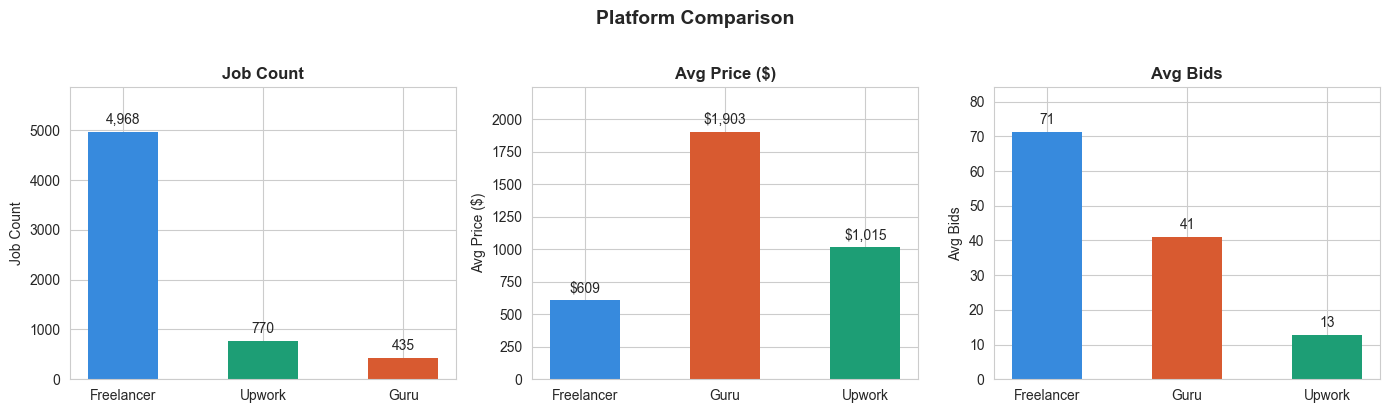

In [15]:
PALETTE = {"Freelancer": "#378ADD", "Upwork": "#1D9E75", "Guru": "#D85A30"}
counts = df["platform"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Platform Comparison", fontsize=14, fontweight="bold", y=1.02)

metrics = [
    ("Job Count",      counts,                                             ""),
    ("Avg Price ($)",  df.groupby("platform")["price_mid"].mean().round(1), "$"),
    ("Avg Bids",       df.groupby("platform")["Bids"].mean().round(1),      ""),
]
for ax, (title, data, prefix) in zip(axes, metrics):
    bars = ax.bar(data.index, data.values,
                  color=[PALETTE[p] for p in data.index],
                  width=0.5, edgecolor="none")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(title, fontsize=10)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + data.max() * 0.02,
                f"{prefix}{val:,.0f}", ha="center", va="bottom",
                fontsize=10, fontweight="500")
    ax.set_ylim(0, data.max() * 1.18)
    ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.show()

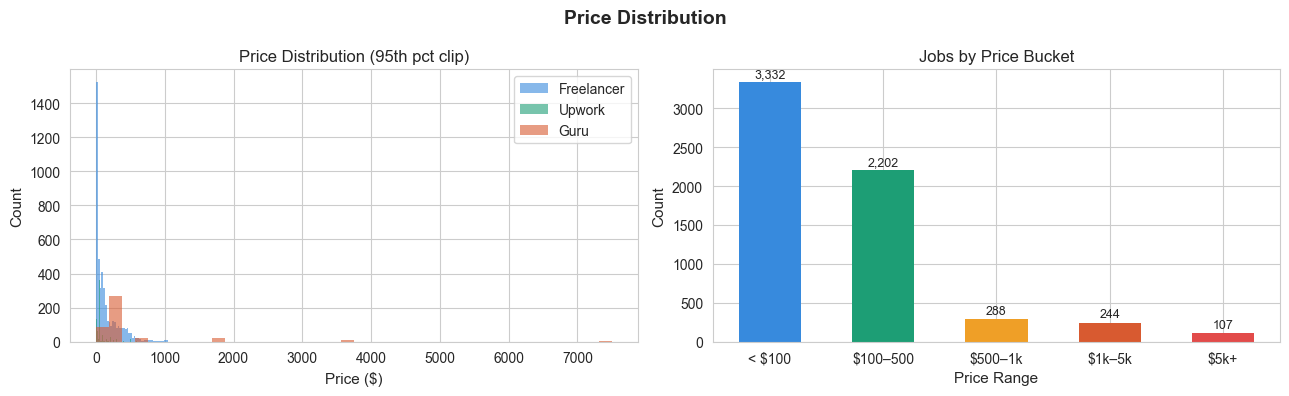

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Price Distribution", fontsize=14, fontweight="bold")

for plat, color in PALETTE.items():
    data = df[df["platform"] == plat]["price_mid"].dropna()
    data_clipped = data[data < data.quantile(0.95)]
    axes[0].hist(data_clipped, bins=40, alpha=0.6, color=color,
                 label=plat, edgecolor="none")
axes[0].set_xlabel("Price ($)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Price Distribution (95th pct clip)", fontsize=12)
axes[0].legend(fontsize=10)

bins   = [0, 100, 500, 1000, 5000, 999999]
labels = ["< $100", "$100–500", "$500–1k", "$1k–5k", "$5k+"]
df["price_bucket"] = pd.cut(df["price_mid"], bins=bins, labels=labels)
bucket_counts = df["price_bucket"].value_counts().reindex(labels)
bar_colors = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30", "#E24B4A"]
bars = axes[1].bar(labels, bucket_counts.values, color=bar_colors,
                   width=0.55, edgecolor="none")
for bar, val in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Jobs by Price Bucket", fontsize=12)
axes[1].set_xlabel("Price Range", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
plt.tight_layout()
plt.show()

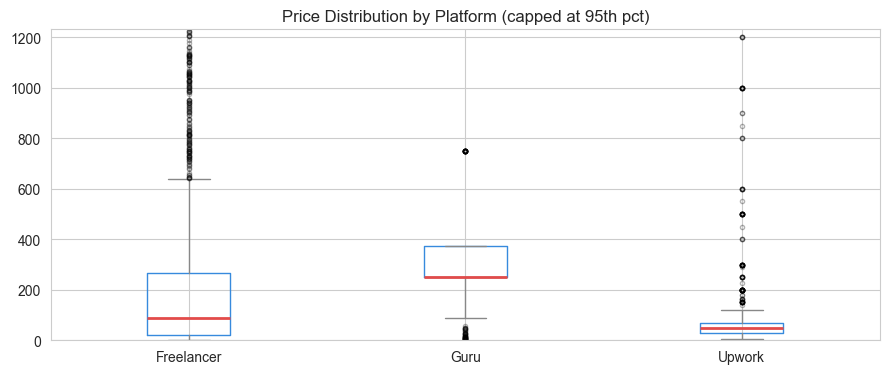

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
df.boxplot(column="price_mid", by="platform", ax=ax,
           boxprops=dict(color="#378ADD"),
           medianprops=dict(color="#E24B4A", lw=2),
           whiskerprops=dict(color="#888"),
           capprops=dict(color="#888"),
           flierprops=dict(marker="o", markersize=3, alpha=0.3, color="#aaa"))
ax.set_ylim(0, df["price_mid"].quantile(0.95) * 1.1)
ax.set_title("Price Distribution by Platform (capped at 95th pct)", fontsize=12)
ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

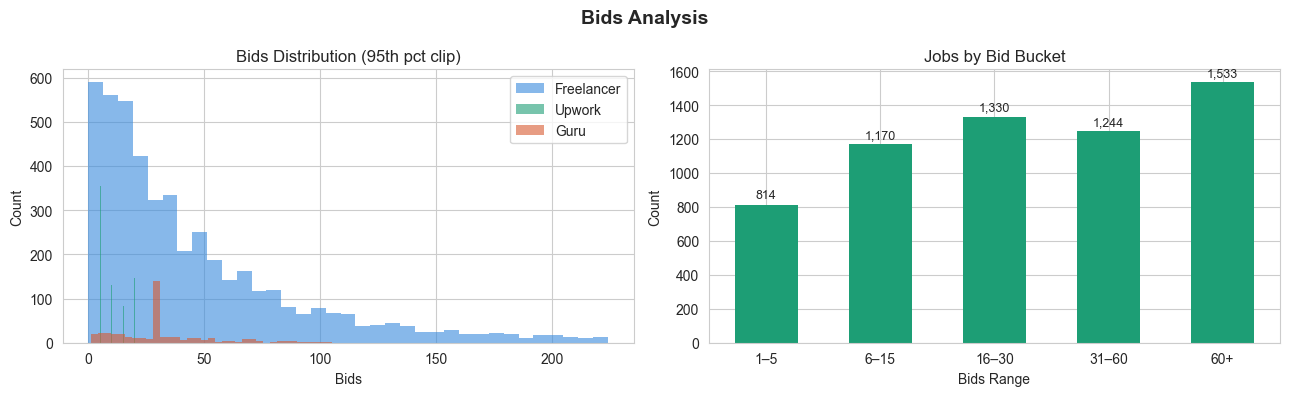

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Bids Analysis", fontsize=14, fontweight="bold")

for plat, color in PALETTE.items():
    d = df[df["platform"] == plat]["Bids"].dropna()
    axes[0].hist(d[d < d.quantile(0.95)], bins=35, alpha=0.6,
                 color=color, label=plat, edgecolor="none")
axes[0].set_title("Bids Distribution (95th pct clip)", fontsize=12)
axes[0].set_xlabel("Bids")
axes[0].set_ylabel("Count")
axes[0].legend()

bbins  = [0, 5, 15, 30, 60, 9999]
blabels = ["1–5", "6–15", "16–30", "31–60", "60+"]
df["bid_bucket"] = pd.cut(df["Bids"], bins=bbins, labels=blabels)
bc = df["bid_bucket"].value_counts().reindex(blabels)
axes[1].bar(blabels, bc.values, color="#1D9E75", width=0.55, edgecolor="none")
for bar, val in zip(axes[1].patches, bc.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Jobs by Bid Bucket", fontsize=12)
axes[1].set_xlabel("Bids Range")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

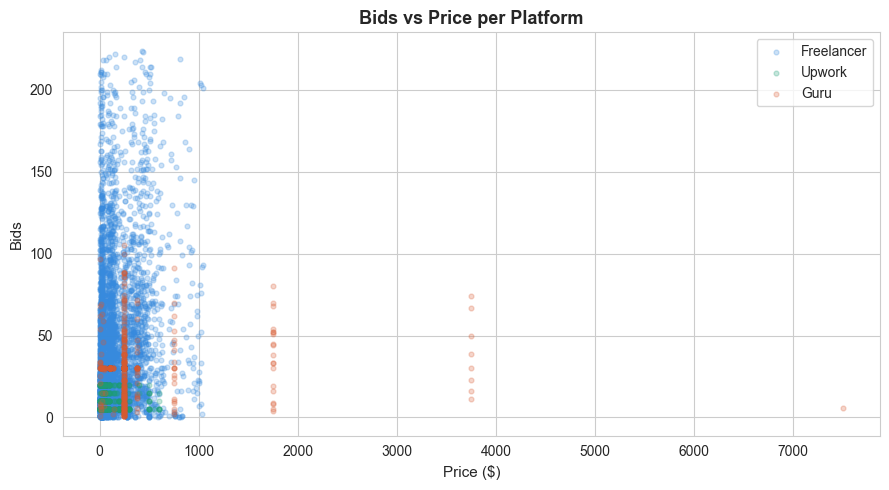

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
for plat, color in PALETTE.items():
    d = df[df["platform"] == plat].copy()
    d = d[(d["price_mid"] < d["price_mid"].quantile(0.95)) &
          (d["Bids"] < d["Bids"].quantile(0.95))]
    ax.scatter(d["price_mid"], d["Bids"], alpha=0.25, s=12,
               color=color, label=plat)
ax.set_xlabel("Price ($)", fontsize=11)
ax.set_ylabel("Bids", fontsize=11)
ax.set_title("Bids vs Price per Platform", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

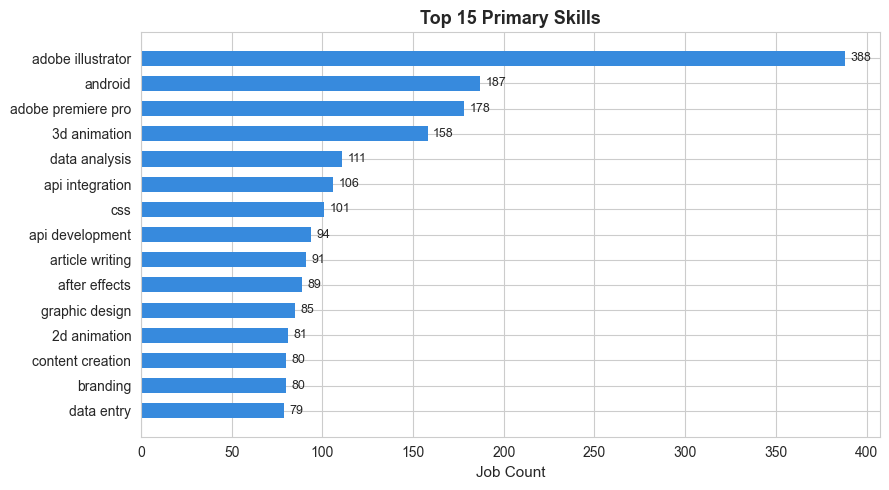

In [20]:
top15 = df["primary_skill"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color="#378ADD", height=0.6, edgecolor="none")
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 3,
            bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
ax.set_title("Top 15 Primary Skills", fontsize=13, fontweight="bold")
ax.set_xlabel("Job Count", fontsize=11)
plt.tight_layout()
plt.show()

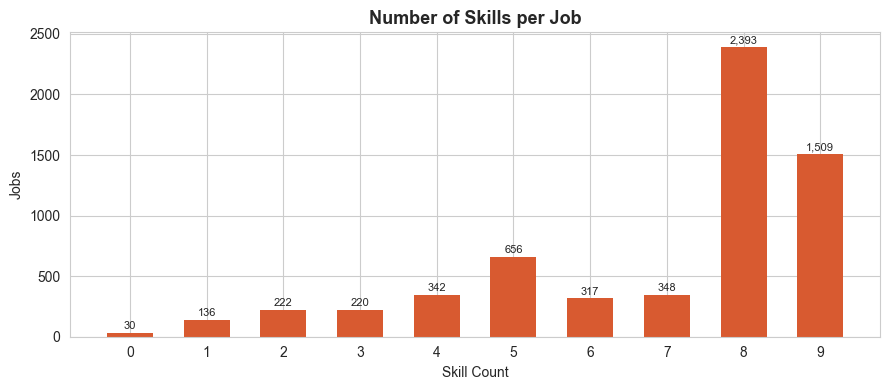

In [21]:
sc = df["skill_count"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(sc.index.astype(str), sc.values,
              color="#D85A30", width=0.6, edgecolor="none")
for bar, val in zip(bars, sc.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            f"{val:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Number of Skills per Job", fontsize=13, fontweight="bold")
ax.set_xlabel("Skill Count")
ax.set_ylabel("Jobs")
plt.tight_layout()
plt.show()

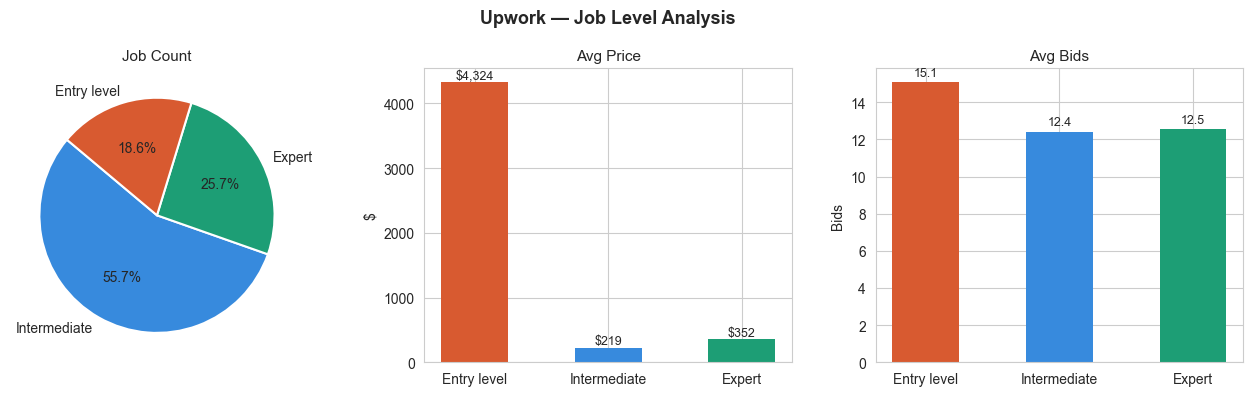

In [22]:
upwork_df = df[df["platform"] == "Upwork"].copy()
upwork_df["Level"] = upwork_df["Level"].fillna("Unknown").str.strip()
upwork_df = upwork_df[upwork_df["Level"].isin(["Intermediate","Expert","Entry level"])]

lev_colors = {"Intermediate": "#378ADD", "Expert": "#1D9E75", "Entry level": "#D85A30"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Upwork — Job Level Analysis", fontsize=13, fontweight="bold")

cnt = upwork_df["Level"].value_counts()
axes[0].pie(cnt.values, labels=cnt.index, autopct="%1.1f%%",
            colors=[lev_colors[l] for l in cnt.index],
            startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Job Count", fontsize=11)

ap = upwork_df.groupby("Level")["price_mid"].mean().reindex(
    ["Entry level","Intermediate","Expert"])
axes[1].bar(ap.index, ap.values,
            color=[lev_colors[l] for l in ap.index],
            width=0.5, edgecolor="none")
for bar, val in zip(axes[1].patches, ap.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Avg Price", fontsize=11)
axes[1].set_ylabel("$")

ab = upwork_df.groupby("Level")["Bids"].mean().reindex(
    ["Entry level","Intermediate","Expert"])
axes[2].bar(ab.index, ab.values,
            color=[lev_colors[l] for l in ab.index],
            width=0.5, edgecolor="none")
for bar, val in zip(axes[2].patches, ab.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)
axes[2].set_title("Avg Bids", fontsize=11)
axes[2].set_ylabel("Bids")
plt.tight_layout()
plt.show()

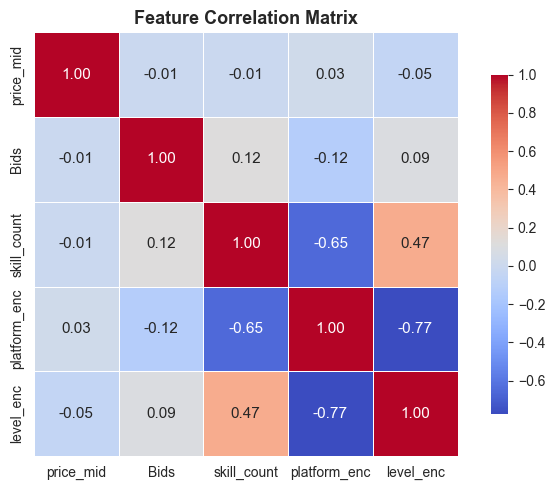

In [23]:
df_corr = df[["price_mid","Bids","skill_count","platform"]].copy()
df_corr["platform_enc"] = LabelEncoder().fit_transform(df_corr["platform"])
df_corr.drop(columns=["platform"], inplace=True)
if "Level" in df.columns:
    df_corr["level_enc"] = LabelEncoder().fit_transform(
        df["Level"].fillna("Unknown"))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 11},
            square=True, cbar_kws={"shrink": .8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
insights = [
    ("Platform Volume",
     ["Freelancer dominates: 80% of all jobs (4,968)",
      "Guru: 7%  |  Upwork: 13%"]),
    ("Pricing",
     ["Guru jobs are 3x pricier than Freelancer on average",
      "54% of all jobs priced below $100",
      "Heavy right skew — median much lower than mean"]),
    ("Competition (Bids)",
     ["Freelancer most competitive: avg 71 bids/job",
      "Upwork least competitive: avg 13 bids/job",
      "24% of jobs attract 60+ bids"]),
    ("Skills",
     ["Adobe Illustrator most demanded (388 jobs)",
      "Most jobs list 8-9 skills",
      "Android & animation skills highly requested"]),
    ("Missing Data",
     ["Level col: 87.5% missing (Upwork-only feature)",
      "Skill9: 75.6%  |  price_min/max: 8.5%"]),
]

for title, points in insights:
    print(f"\n{'='*52}")
    print(f"  {title}")
    print(f"{'='*52}")
    for p in points:
        print(f"  • {p}")


  Platform Volume
  • Freelancer dominates: 80% of all jobs (4,968)
  • Guru: 7%  |  Upwork: 13%

  Pricing
  • Guru jobs are 3x pricier than Freelancer on average
  • 54% of all jobs priced below $100
  • Heavy right skew — median much lower than mean

  Competition (Bids)
  • Freelancer most competitive: avg 71 bids/job
  • Upwork least competitive: avg 13 bids/job
  • 24% of jobs attract 60+ bids

  Skills
  • Adobe Illustrator most demanded (388 jobs)
  • Most jobs list 8-9 skills
  • Android & animation skills highly requested

  Missing Data
  • Level col: 87.5% missing (Upwork-only feature)
  • Skill9: 75.6%  |  price_min/max: 8.5%
